# 2.4 DataFrame Exploration and Cleaning

Before any modeling, you need to know what is in your table. This lesson walks through a standard preparation pipeline on a pandas DataFrame: read the data, inspect types and summary statistics, handle missing values, decide what to do with zeros, and explore correlations and per-class distributions.

The dataset is a synthetic whole-rock geochemistry survey generated by the course package `mlgeo_synth`. Each row is one rock sample with:

* **Major-element oxides** (SIO2, AL2O3, FEO, MGO, CAO, NA2O, K2O) in weight percent (wt%),
* **density_g_cm3**: bulk density in g/cm3,
* **mag_susc_si**: magnetic susceptibility (SI units),
* **label**: the lithology (granite, basalt, andesite), which a classifier would later try to predict.

The generator plants realistic correlations: a latent differentiation index drives the oxides, so SiO2 anticorrelates with FeO, MgO, and CaO, and density tracks the mafic oxides. Your job in this lesson is to recover those relationships from the table.

## 1. Read and Explore the Data

In [1]:
import pandas as pd
import numpy as np
import mlgeo_synth

df = mlgeo_synth.geochem_table(n=10000, seed=42)
df.head()

,SIO2,AL2O3,FEO,MGO,CAO,NA2O,K2O,density_g_cm3,mag_susc_si,label
0,45.911630,16.274633,11.975374,9.696094,12.753069,2.080147,0.000000,3.006341,0.000440,basalt
1,68.266983,14.422233,4.859297,2.240226,4.761345,3.047384,3.424764,2.692516,0.000165,granite
2,50.417246,15.268785,8.214010,5.851874,10.378347,2.554201,1.235895,2.939080,0.001338,basalt
3,46.502363,14.569045,11.726829,7.618624,12.454581,1.244922,0.000000,3.001760,0.001120,basalt
4,68.305243,13.592871,3.457937,2.516258,3.781839,3.270665,3.738746,2.682556,0.000087,granite


In [2]:
# what datatypes are in the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SIO2           10000 non-null  float64
 1   AL2O3          10000 non-null  float64
 2   FEO            10000 non-null  float64
 3   MGO            10000 non-null  float64
 4   CAO            10000 non-null  float64
 5   NA2O           10000 non-null  float64
 6   K2O            10000 non-null  float64
 7   density_g_cm3  10000 non-null  float64
 8   mag_susc_si    10000 non-null  float64
 9   label          10000 non-null  str    
dtypes: float64(9), str(1)
memory usage: 847.3 KB


The column ``label`` holds strings, everything else is numeric. Check the summary statistics next. Read the min and max rows against physical expectations: oxides should sit between 0 and 100 wt%, and crustal rock densities between roughly 2.5 and 3.3 g/cm3.

In [3]:
# Summary statistics
df.describe()

,SIO2,AL2O3,FEO,MGO,CAO,NA2O,K2O,density_g_cm3,mag_susc_si
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,62.683048,14.642958,5.518821,3.507023,5.489981,3.176207,2.739503,2.769337,0.000520
std,10.968124,1.148082,3.759978,3.227643,4.436243,0.850818,1.823283,0.144232,0.000606
min,41.686955,11.262724,0.000000,0.000000,0.000000,0.092059,0.000000,2.503250,0.000018
25%,50.103553,13.850434,2.305713,0.613202,1.604526,2.586516,0.926125,2.645018,0.000093
50%,69.214045,14.475739,4.191070,2.201551,3.358273,3.213133,3.210102,2.698103,0.000191
75%,72.294157,15.227731,9.296822,6.856880,10.376314,3.770548,4.309348,2.930363,0.000819
max,81.019298,19.072472,15.184024,11.303776,14.695311,6.731240,7.037632,3.086072,0.006552


In [4]:
# How many samples per lithology?
df['label'].value_counts()

label
granite     5525
basalt      3490
andesite     985
Name: count, dtype: int64

The classes are imbalanced: granites outnumber andesites by more than five to one. Keep that number in mind; it comes back in the exercise.

## 2. Handling Missing Values (NaNs)

Field and lab datasets have gaps: a sensor fails, a lab skips an analysis, a value is dropped during transcription. In pandas, missing values appear as ``NaN`` or the newer ``pd.NA``. Common strategies:

* **Remove rows/columns with missing values**: fine when the missing fraction is small and missingness is unrelated to the value itself.
* **Impute**: fill gaps with a mean, median, interpolation, or a model-based estimate. Imputation keeps sample size but injects assumptions.

This synthetic table comes out of the generator complete, which real data never is. To give the lesson something to clean, we deliberately knock out a small random fraction of the density and magnetic susceptibility measurements, and we set a few density values to 0 to mimic an instrument that writes 0 when a measurement fails. This kind of "sentinel" zero is common in real archives.

In [5]:
# Deliberately introduce missing data (this is the simulation of a messy archive)
rng = np.random.default_rng(42)

# 2% of density and 3% of susceptibility go missing
mask_density = rng.random(len(df)) < 0.02
mask_susc = rng.random(len(df)) < 0.03
df.loc[mask_density, 'density_g_cm3'] = pd.NA
df.loc[mask_susc, 'mag_susc_si'] = pd.NA

# 15 sentinel zeros in density: the "instrument failure" code
sentinel_rows = rng.choice(len(df), size=15, replace=False)
df.loc[df.index[sentinel_rows], 'density_g_cm3'] = 0.0

In [6]:
# Check for missing values
print(df.isna().sum())

SIO2               0
AL2O3              0
FEO                0
MGO                0
CAO                0
NA2O               0
K2O                0
density_g_cm3    187
mag_susc_si      302
label              0
dtype: int64


Note the modern pandas style used above: we assign with ``df.loc[mask, col] = value`` and reassign results (``df = df.something()``) instead of using ``inplace=True`` on views or slices. Chained inplace operations on a slice of a DataFrame raise errors in pandas 3.

## 3. Zeros: Physical Value or Missing-Data Code?

A tempting shortcut is "replace all zeros with NA". Do not do this. Whether a zero is real depends on the physics of the variable:

* **MgO near 0 wt% is real.** Highly evolved granites can have essentially no magnesium left; the melt has fractionated it out. The same goes for FeO, CaO, and K2O in the right rock types. Deleting those zeros would preferentially delete evolved granites and bias the dataset.
* **A density of 0 g/cm3 is impossible.** No rock has zero density. A zero there is a sentinel: a code some instrument or database used to mean "no measurement".

The check is simple: count zeros per column and ask, for each column, whether zero is inside the physically possible range.

In [7]:
# Count zeros per numeric column
numeric_cols = df.select_dtypes(include='number').columns
print((df[numeric_cols] == 0).sum())

SIO2                0
AL2O3               0
FEO               184
MGO              1434
CAO               367
NA2O                0
K2O               824
density_g_cm3      15
mag_susc_si         0
dtype: int64


Thousands of oxide zeros, and exactly the 15 density zeros we planted. Now look at which rocks carry the MgO zeros.

In [8]:
# Which lithologies have MgO exactly at 0?
print(df.loc[df['MGO'] == 0, 'label'].value_counts())
print("\nMedian SiO2 of MgO=0 samples:", round(df.loc[df['MGO'] == 0, 'SIO2'].median(), 1), "wt%")
print("Median SiO2 of the full table:", round(df['SIO2'].median(), 1), "wt%")

label
granite     1432
andesite       2
Name: count, dtype: int64

Median SiO2 of MgO=0 samples: 74.2 wt%
Median SiO2 of the full table: 69.2 wt%


The MgO zeros are almost all granites, and they are silica-rich ones. That is exactly the geochemical expectation for evolved melts: these zeros carry information. We keep them.

The density zeros are a different story. Replace only those with ``pd.NA``, by assignment, not inplace.

In [9]:
# Convert only the impossible zeros (density) to missing values
df = df.replace({'density_g_cm3': {0.0: pd.NA}})
print(df.isna().sum())

SIO2               0
AL2O3              0
FEO                0
MGO                0
CAO                0
NA2O               0
K2O                0
density_g_cm3    202
mag_susc_si      302
label              0
dtype: int64


## 4. Dropping the Incomplete Rows

The missing fraction is small (about 5% of rows have at least one gap) and, by construction here, unrelated to the values themselves, so dropping is defensible. With real data you would first ask *why* values are missing before dropping anything.

In [10]:
df_cleaned = df.dropna()
print(f"Rows before: {len(df)}, after dropping incomplete rows: {len(df_cleaned)}")
df_cleaned.info()

Rows before: 10000, after dropping incomplete rows: 9499
<class 'pandas.DataFrame'>
Index: 9499 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SIO2           9499 non-null   float64
 1   AL2O3          9499 non-null   float64
 2   FEO            9499 non-null   float64
 3   MGO            9499 non-null   float64
 4   CAO            9499 non-null   float64
 5   NA2O           9499 non-null   float64
 6   K2O            9499 non-null   float64
 7   density_g_cm3  9499 non-null   object 
 8   mag_susc_si    9499 non-null   float64
 9   label          9499 non-null   str    
dtypes: float64(8), object(1), str(1)
memory usage: 880.1+ KB


In [11]:
# Final check: no missing values, class counts still imbalanced but intact
print(df_cleaned.isna().sum())
print()
print(df_cleaned['label'].value_counts())

SIO2             0
AL2O3            0
FEO              0
MGO              0
CAO              0
NA2O             0
K2O              0
density_g_cm3    0
mag_susc_si      0
label            0
dtype: int64

label
granite     5182
basalt      3357
andesite     960
Name: count, dtype: int64


## 5. Correlation Analysis

Correlations between features tell you which measurements carry redundant information and hint at the physics behind the table. We compute two matrices:

* **Pearson** correlation measures *linear* relationships.
* **Spearman** rank correlation measures *monotonic* relationships. It is robust to outliers and to nonlinear but monotonic links, which are common in geochemistry.

The ``label`` column is a string, so first keep only the numeric columns.

In [12]:
df_numerical = df_cleaned.select_dtypes(include='number')
df_numerical.head()

,SIO2,AL2O3,FEO,MGO,CAO,NA2O,K2O,mag_susc_si
0,45.911630,16.274633,11.975374,9.696094,12.753069,2.080147,0.000000,0.000440
1,68.266983,14.422233,4.859297,2.240226,4.761345,3.047384,3.424764,0.000165
2,50.417246,15.268785,8.214010,5.851874,10.378347,2.554201,1.235895,0.001338
3,46.502363,14.569045,11.726829,7.618624,12.454581,1.244922,0.000000,0.001120
4,68.305243,13.592871,3.457937,2.516258,3.781839,3.270665,3.738746,0.000087


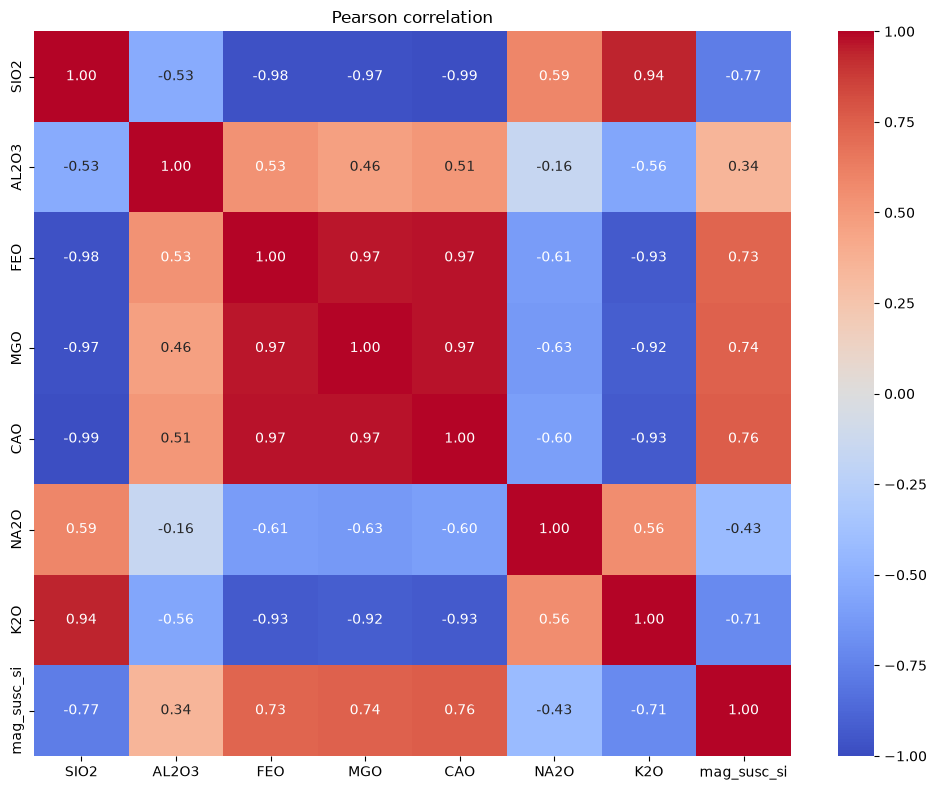

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df_numerical.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Pearson correlation')
plt.tight_layout()
plt.show()

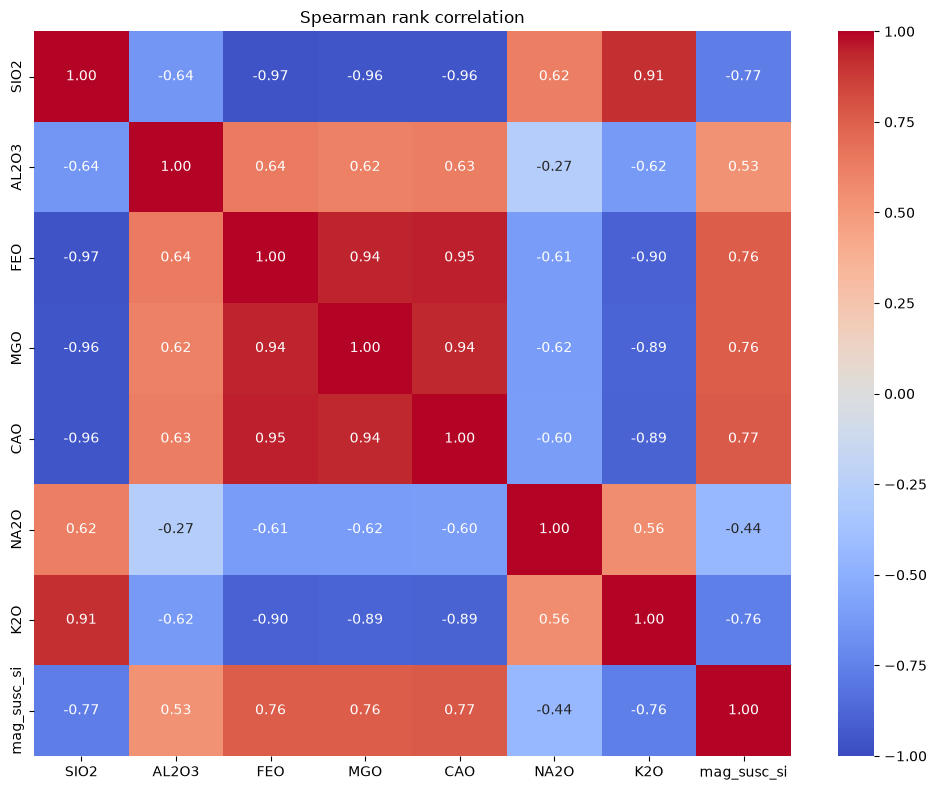

In [14]:
spearman_corr_matrix = df_numerical.corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(spearman_corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Spearman rank correlation')
plt.tight_layout()
plt.show()

Read the two matrices side by side. SiO2 is strongly anticorrelated with FeO, MgO, and CaO, and positively correlated with K2O. Density tracks the mafic oxides and anticorrelates with SiO2. Where the Spearman value is noticeably stronger than the Pearson value, the relationship is monotonic but not linear; magnetic susceptibility is a typical case, since it spans orders of magnitude.

One structural reason for the negative correlations: oxide analyses are **compositional data**. The wt% values of the major oxides sum to roughly 100, so if one oxide goes up, the others must come down. This closure effect builds negative correlation into the table regardless of any petrology. Keep it in mind before interpreting every negative entry as a geological process.

## 6. Feature Distributions per Lithology

Correlation matrices pool all classes together. To see which features separate the lithologies, plot each feature's distribution per class.

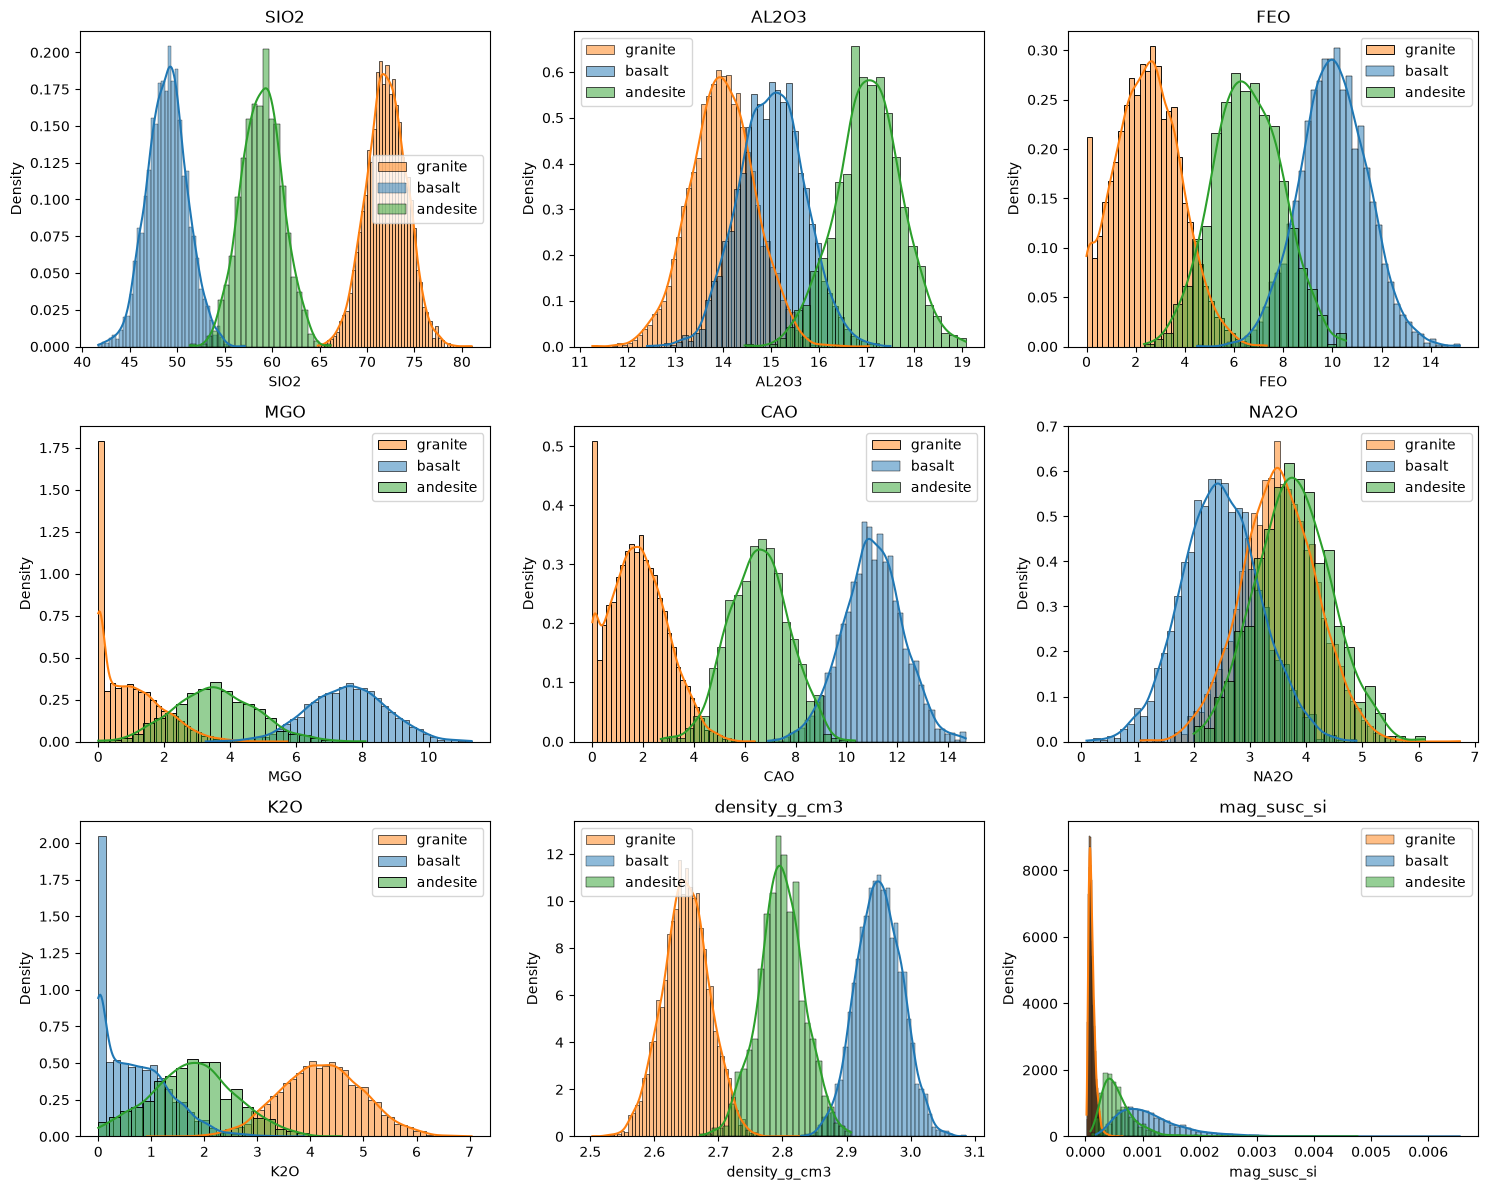

In [15]:
granite = df_cleaned[df_cleaned['label'] == 'granite']
basalt = df_cleaned[df_cleaned['label'] == 'basalt']
andesite = df_cleaned[df_cleaned['label'] == 'andesite']

features = ['SIO2', 'AL2O3', 'FEO', 'MGO', 'CAO', 'NA2O', 'K2O', 'density_g_cm3', 'mag_susc_si']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for ax, feature in zip(axes.ravel(), features):
    sns.histplot(granite[feature], kde=True, color='tab:orange', label='granite', stat='density', ax=ax)
    sns.histplot(basalt[feature], kde=True, color='tab:blue', label='basalt', stat='density', ax=ax)
    sns.histplot(andesite[feature], kde=True, color='tab:green', label='andesite', stat='density', ax=ax)
    ax.set_title(feature)
    ax.legend()
plt.tight_layout()
plt.show()

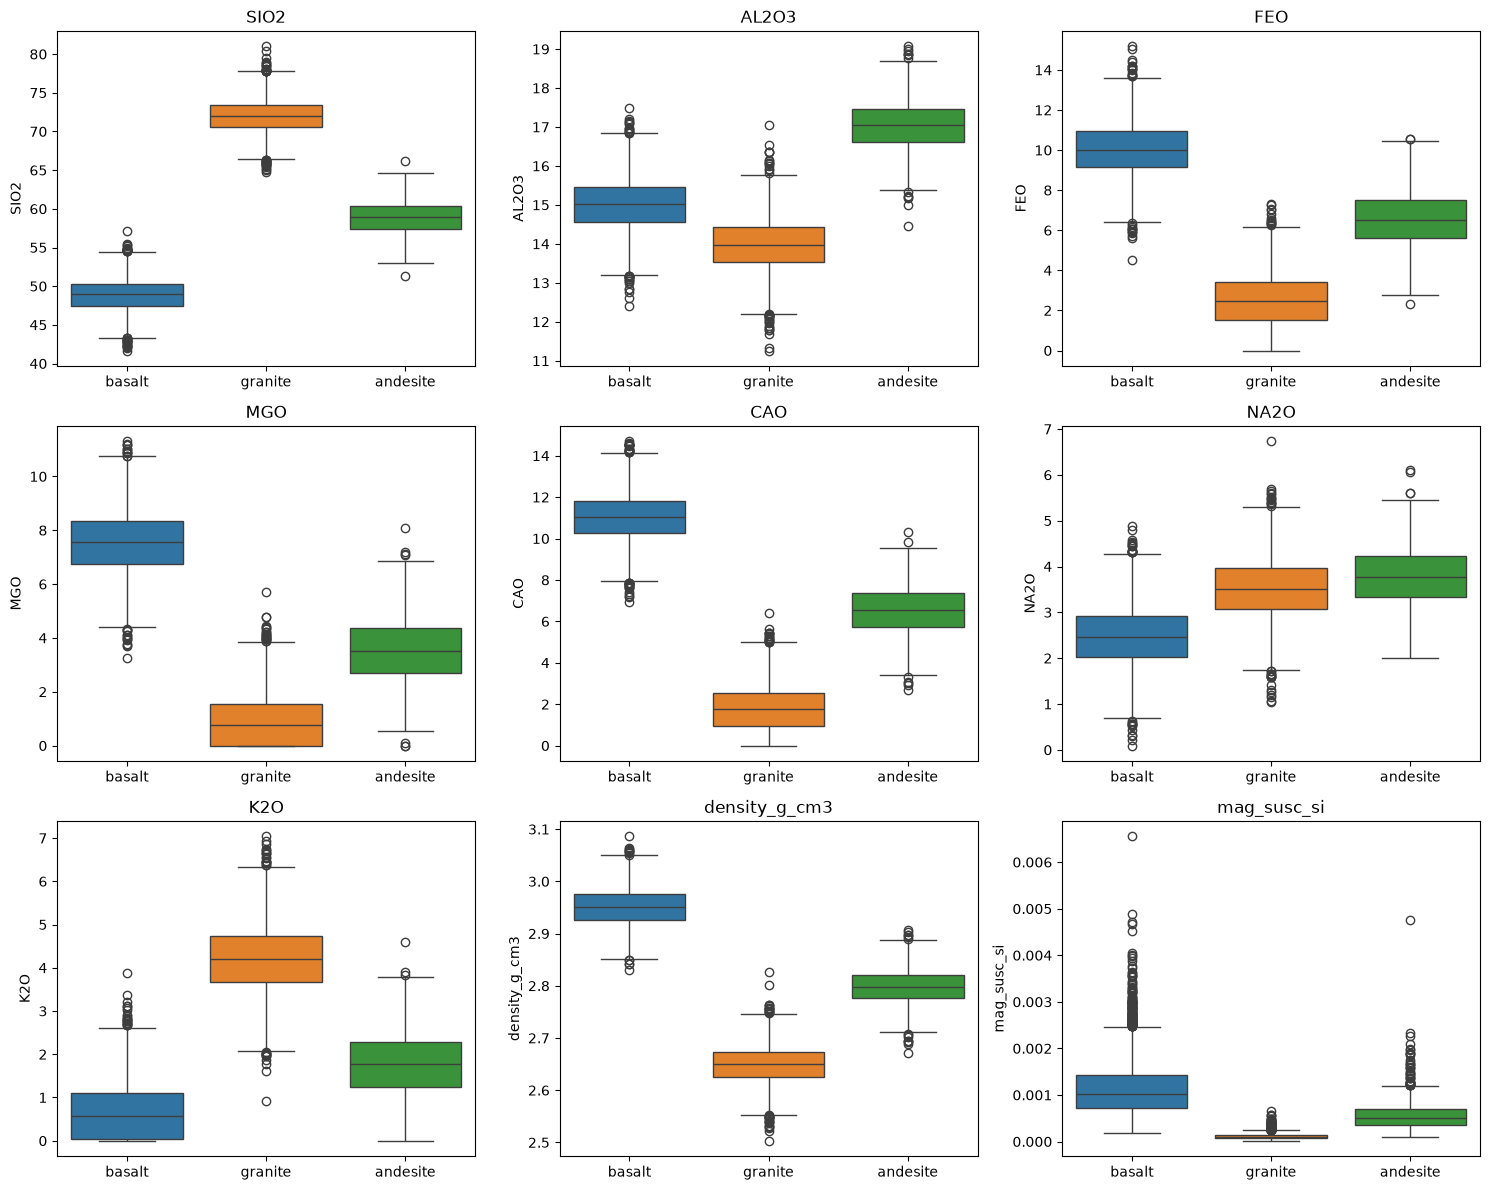

In [16]:
# Boxplots give a compact per-class view of the same information
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for ax, feature in zip(axes.ravel(), features):
    sns.boxplot(data=df_cleaned, x='label', y=feature, hue='label', ax=ax)
    ax.set_title(feature)
    ax.set_xlabel('')
plt.tight_layout()
plt.show()

Some features separate the classes almost completely; others overlap heavily. Some distributions look roughly Gaussian, others are skewed or heavy-tailed. To quantify shape, compute skewness and kurtosis alongside the usual moments.

In [17]:
from scipy.stats import skew, kurtosis

def summarize_distribution(frame, features):
    summary = {}
    for feature in features:
        values = frame[feature].to_numpy(dtype=float)
        summary[feature] = {
            'mean': values.mean(),
            'median': np.median(values),
            'std': values.std(),
            'skewness': skew(values),
            'kurtosis': kurtosis(values),
        }
    return pd.DataFrame(summary)

print("Granite:")
print(summarize_distribution(granite, features).round(3))
print("\nBasalt:")
print(summarize_distribution(basalt, features).round(3))
print("\nAndesite:")
print(summarize_distribution(andesite, features).round(3))

Granite:
            SIO2   AL2O3    FEO    MGO    CAO   NA2O    K2O  density_g_cm3  \
mean      72.043  13.981  2.481  0.947  1.799  3.511  4.213          2.650   
median    72.040  13.977  2.477  0.756  1.753  3.503  4.210          2.649   
std        2.128   0.677  1.319  0.930  1.129  0.672  0.785          0.037   
skewness  -0.007  -0.001  0.180  0.880  0.332 -0.003  0.033         -0.006   
kurtosis   0.015   0.121 -0.326  0.191 -0.370  0.061 -0.067          0.058   

          mag_susc_si  
mean            0.000  
median          0.000  
std             0.000  
skewness        1.796  
kurtosis        5.938  

Basalt:
            SIO2   AL2O3     FEO    MGO     CAO   NA2O    K2O  density_g_cm3  \
mean      48.931  15.014  10.044  7.547  11.032  2.479  0.677          2.951   
median    48.976  15.028  10.029  7.564  11.025  2.470  0.571          2.951   
std        2.121   0.681   1.367  1.187   1.187  0.690  0.631          0.036   
skewness   0.001  -0.002   0.017 -0.031  -0.038  

Skewness near 0 and kurtosis near 0 (scipy uses the excess-kurtosis convention) indicate a roughly Gaussian shape. Large positive skewness, as in magnetic susceptibility, signals a heavy right tail; such features are often log-transformed before modeling.

Save the cleaned table for later chapters.

In [18]:
df_cleaned.to_csv('cleaned_geochem.csv', index=False)
df_cleaned.describe()

,SIO2,AL2O3,FEO,MGO,CAO,NA2O,K2O,mag_susc_si
count,9499.000000,9499.000000,9499.000000,9499.000000,9499.000000,9499.000000,9499.000000,9499.000000
mean,62.547694,14.655570,5.564598,3.542369,5.542651,3.173276,2.717094,0.000526
std,10.981083,1.153150,3.765145,3.235125,4.441995,0.853688,1.822599,0.000609
min,41.686955,11.262724,0.000000,0.000000,0.000000,0.092059,0.000000,0.000018
25%,50.039458,13.859048,2.323911,0.624757,1.623670,2.579347,0.917860,0.000094
50%,69.082701,14.484437,4.261370,2.244728,3.443124,3.209799,3.161037,0.000199
75%,72.246668,15.246425,9.320874,6.890419,10.420669,3.771248,4.296074,0.000826
max,81.019298,19.072472,15.184024,11.303776,14.695311,6.731240,7.037632,0.006552


## 7. Exercise

Answer with code and a short written justification for each question.

1. **Correlations and closure.** From the Pearson matrix, list the three strongest anticorrelations with SiO2. How much of that anticorrelation is petrology (mafic minerals fractionating out as melts evolve) and how much is the closure effect (major oxides summing to ~100 wt%, so one rising forces others down)? Propose one check that could help separate the two explanations.
2. **Best separating feature.** Using the per-class histograms and the summary statistics, which single feature best separates the three lithologies? Support your choice quantitatively, for example by comparing the difference in class means to the class standard deviations for each feature.
3. **Class imbalance.** Granites make up more than half the table and andesites about 10%. If you trained a classifier on this table and measured only overall accuracy, what accuracy would a model that always predicts "granite" achieve? What does that imply about how you should evaluate a future classifier on this dataset?
4. **Zeros revisited.** Suppose a colleague hands you a version of this table where all MgO zeros were already replaced with NaN and dropped. Which class would lose the most samples, and how would the SiO2 distribution of the remaining granites change?

In [19]:
# your answers here